# Clustering Jerárquico — Presentación (Iris)
### Para adaptar a otro dataset o distancia: edita solo el bloque de configuración y ejecuta todo de arriba a abajo.

In [366]:
# ╔══════════════════════════════════════════════════════╗
# ║         BLOQUE DE CONFIGURACIÓN — EDITAR AQUÍ        ║
# ╚══════════════════════════════════════════════════════╝

# --- Dataset -------------------------------------------------
# Opción A: CSV en la misma carpeta que este notebook
# Opción B: pon USE_SKLEARN = True y elige el dataset de sklearn
USE_SKLEARN = True             # False → carga CSV_PATH
CSV_PATH    = 'datos.csv'
LABEL_COL   = 'species'        # columna con clases reales; None si no hay etiquetas

# --- Clustering ----------------------------------------------
DISTANCIA = 'cityblock'        # 'euclidean' | 'cityblock' | 'mahalanobis' | 'cosine'
METHOD    = 'average'             # 'ward' | 'complete' | 'average' | 'single'

# --- Visual --------------------------------------------------
TITULO = 'Iris — Distancia L1 / Average'

---
## 0 · Librerías

In [367]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.spatial.distance import pdist
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from plotly.subplots import make_subplots
from matplotlib import cm
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score

---
## 1 · Carga, preprocesado y presentación del dataset

In [368]:
# Carga el dataset
if USE_SKLEARN:
    from sklearn.datasets import load_iris   # ← cambia el dataset de sklearn, por ejemplo load_wine
    raw = load_iris(as_frame=True)
    df  = raw.data.copy()
    df['species'] = pd.Categorical.from_codes(raw.target, raw.target_names)
else:
    df = pd.read_csv(CSV_PATH)
    
# Extrae etiquetas reales si las hay
y_true, clases = None, None
if LABEL_COL and LABEL_COL in df.columns:
    le     = LabelEncoder()
    y_true = le.fit_transform(df[LABEL_COL])
    clases = le.classes_

# Selecciona solo variables numéricas
df_num = df.drop(columns=[LABEL_COL] if LABEL_COL and LABEL_COL in df.columns else []
                 ).select_dtypes(include=np.number)

X_csv = df_num.values
# Normaliza el dataset para no tener escalas dispares entre covariables
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_csv)

In [369]:
# Datos originales
print('── Datos originales ──')
display(pd.DataFrame(X_csv, columns=df_num.columns).round(2))

# Datos escalados
print('── Datos escalados (StandardScaler) ──')
display(pd.DataFrame(X_scaled, columns=df_num.columns).round(3))

── Datos originales ──


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


── Datos escalados (StandardScaler) ──


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.901,1.019,-1.340,-1.315
1,-1.143,-0.132,-1.340,-1.315
2,-1.385,0.328,-1.397,-1.315
3,-1.507,0.098,-1.283,-1.315
4,-1.022,1.249,-1.340,-1.315
...,...,...,...,...
145,1.038,-0.132,0.820,1.449
146,0.553,-1.283,0.706,0.922
147,0.796,-0.132,0.820,1.054
148,0.432,0.789,0.933,1.449


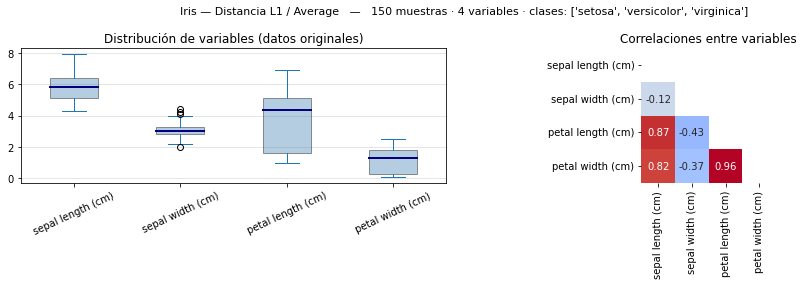

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [370]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot de cada variable — muestra distribución y escala relativa entre features
df_num.plot(kind='box', ax=axes[0], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.4),
            medianprops=dict(color='navy', linewidth=2))
axes[0].set_title('Distribución de variables (datos originales)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.4)

# Mapa de correlaciones — justifica visualmente la elección de distancia
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], square=True, cbar=False, mask=mask,
            annot_kws={'size': 10})
axes[1].set_title('Correlaciones entre variables')

etiq = f' · clases: {list(clases)}' if clases is not None else ''
plt.suptitle(f'{TITULO}   —   {len(X_csv)} muestras · {X_csv.shape[1]} variables{etiq}',
             fontsize=11)
plt.tight_layout()
plt.show()

# Tabla resumen compacta
df_num.describe().round(2)

---
## 2 · Visualización inicial de los datos (PCA)

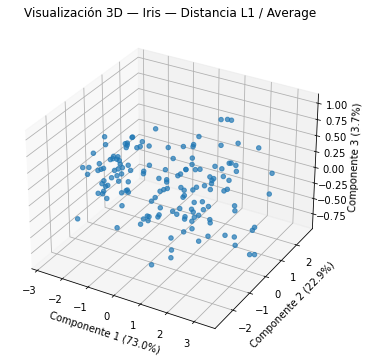

In [371]:
# Si el dataset cuenta con más de 3 dimensiones, reduce a 3 para graficar y visualizar
n_dim = min(3, X_scaled.shape[1])
pca   = PCA(n_components=n_dim)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_ * 100

if n_dim == 1:
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], np.zeros_like(X_pca[:,0]), alpha=0.7)
    plt.xlabel(f'Componente 1 ({var[0]:.1f}%)')
    plt.title(f'Visualización 1D — {TITULO}')
    plt.grid(True)
    plt.show()
elif n_dim == 2:
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    plt.xlabel(f'Componente 1 ({var[0]:.1f}%)')
    plt.ylabel(f'Componente 2 ({var[1]:.1f}%)')
    plt.title(f'Visualización 2D — {TITULO}')
    plt.grid(True)
    plt.show()
else:  # 3D
    fig = plt.figure(figsize=(8,6))
    ax  = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.7)
    ax.set_xlabel(f'Componente 1 ({var[0]:.1f}%)')
    ax.set_ylabel(f'Componente 2 ({var[1]:.1f}%)')
    ax.set_zlabel(f'Componente 3 ({var[2]:.1f}%)')
    ax.set_title(f'Visualización 3D — {TITULO}')
    plt.show()

---
## 3 · Dendrograma

In [372]:
# Calcula la matriz de distancias y el linkage según DISTANCIA y METHOD
if DISTANCIA == 'mahalanobis':
    cov = np.cov(X_csv.T)
    VI  = np.linalg.inv(cov + np.eye(cov.shape[0]) * 1e-6)
    D   = pdist(X_csv, metric='mahalanobis', VI=VI)
    Z   = linkage(D, method=METHOD)
else:
    Z = linkage(X_scaled, method=METHOD, metric=DISTANCIA)

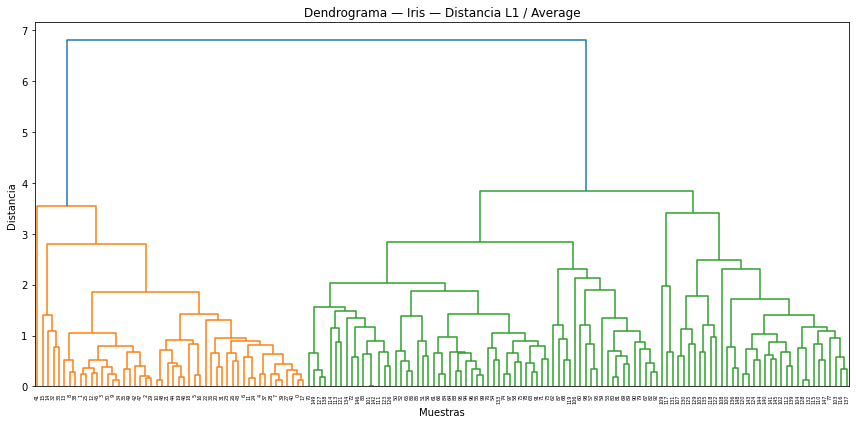

In [373]:
plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title(f'Dendrograma \u2014 {TITULO}')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

In [374]:
linkages = {TITULO: Z}

---
## 4 · Visualización interactiva dendrograma + scatter 3D

In [375]:
palette  = px.colors.qualitative.Plotly
n_colors = len(palette)

def matplotlib_color_to_hex(c):
    if c.startswith('C'):
        cmap = plt.get_cmap('tab10')
        idx  = int(c[1:])
        return mcolors.to_hex(cmap(idx))
    return c


def create_frames_colored(Z, X_scaled, n_steps=20):
    max_dist  = np.max(Z[:,2])
    distances = np.linspace(0, max_dist, n_steps)
    frames    = []

    dendro_full    = dendrogram(Z, no_plot=True)
    icoord, dcoord = dendro_full['icoord'], dendro_full['dcoord']
    x_min = min([min(x) for x in icoord])
    x_max = max([max(x) for x in icoord])

    for d in distances:
        clusters       = fcluster(Z, t=d, criterion='distance')
        cluster_colors = [palette[(c-1)%n_colors] for c in clusters]

        scatter = go.Scatter3d(
            x=X_scaled[:,0], y=X_scaled[:,1], z=X_scaled[:,2],
            mode='markers',
            marker=dict(size=5, color=cluster_colors),
            name='Puntos'
        )

        dendro      = dendrogram(Z, no_plot=True, color_threshold=d)
        icoord_d, dcoord_d, color_list = dendro['icoord'], dendro['dcoord'], dendro['color_list']

        dendro_lines = [go.Scatter(
            x=x, y=y, mode='lines',
            line=dict(color=matplotlib_color_to_hex(c), width=2),
            showlegend=False
        ) for x,y,c in zip(icoord_d, dcoord_d, color_list)]

        cutoff_line = go.Scatter(
            x=[x_min, x_max], y=[d, d],
            mode='lines',
            line=dict(color='red', width=2, dash='dash'),
            name='Corte'
        )

        frames.append(go.Frame(
            data=[scatter] + dendro_lines + [cutoff_line],
            name=str(round(d,2))
        ))

    return frames, distances


for metric, Z in linkages.items():
    frames, distances = create_frames_colored(Z, X_scaled, n_steps=20)

    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.5, 0.5],
        vertical_spacing=0.1,
        specs=[[{}], [{"type": "scene"}]],
        subplot_titles=[f"Dendrograma - {metric}", "Scatter 3D"]
    )

    fig.add_trace(go.Scatter3d(
        x=X_scaled[:,0], y=X_scaled[:,1], z=X_scaled[:,2],
        mode='markers',
        marker=dict(size=5, color='gray'),
        name='Datos'
    ), row=2, col=1)

    dendro         = dendrogram(Z, no_plot=True)
    icoord, dcoord = dendro['icoord'], dendro['dcoord']
    for x, y in zip(icoord, dcoord):
        fig.add_trace(go.Scatter(
            x=x, y=y, mode='lines',
            line=dict(color='black'),
            showlegend=False
        ), row=1, col=1)

    x_min = min([min(x) for x in icoord])
    x_max = max([max(x) for x in icoord])
    fig.add_trace(go.Scatter(
        x=[x_min, x_max], y=[0, 0],
        mode='lines',
        line=dict(color='red', width=2, dash='dash'),
        name='Corte'
    ), row=1, col=1)

    fig.frames = frames

    sliders = [dict(
        active=0,
        currentvalue={"prefix": "Distancia de corte: "},
        pad={"t": 50},
        steps=[dict(
            method='animate',
            args=[[str(round(d,2))],
                  dict(mode='immediate',
                       frame=dict(duration=500, redraw=True),
                       transition=dict(duration=0))],
            label=str(round(d,2))
        ) for d in distances]
    )]

    fig.update_layout(
        height=900,
        title_text=f"Clustering Interactivo 3D - {metric}",
        sliders=sliders,
        updatemenus=[dict(
            type="buttons",
            buttons=[
                dict(label="Play", method="animate",
                     args=[None, dict(frame=dict(duration=500, redraw=True),
                                     fromcurrent=True, mode='immediate')]),
                dict(label="Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                       mode='immediate')])
            ]
        )]
    )

    fig.show()

---
## 5 · Evaluación

Primero se calcula el **Silhouette Score** para dar un valor de k (el número de clusters) óptimo y que no dependa de información exterior. Sirve para verificar lo visto en el dendrograma.

- **Con etiquetas reales** (`LABEL_COL` definido): matriz de confusión
- **Sin etiquetas** (`LABEL_COL = None`): perfil medio de cada cluster

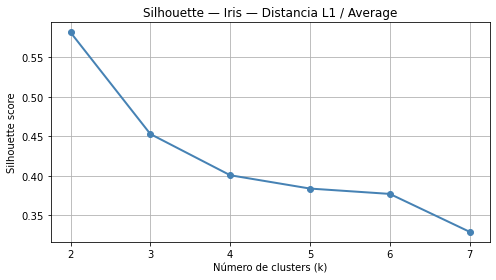

k óptimo según silhouette: 2  (score: 0.582)


In [376]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

k_valores = range(2, 8)
scores = []

# Si la distancia es Mahalanobis, el silhouette debe usar D directamente
# Para el resto, X_scaled con distancia euclídea es correcto
if DISTANCIA == 'mahalanobis':
    D_matrix = squareform(D)
    for k in k_valores:
        y_k = fcluster(Z, t=k, criterion='maxclust') - 1
        scores.append(silhouette_score(D_matrix, y_k, metric='precomputed'))
else:
    for k in k_valores:
        y_k = fcluster(Z, t=k, criterion='maxclust') - 1
        scores.append(silhouette_score(X_scaled, y_k))

plt.figure(figsize=(7, 4))
plt.plot(k_valores, scores, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.title(f'Silhouette — {TITULO}')
plt.xticks(k_valores)
plt.grid(True)
plt.tight_layout()
plt.show()

k_optimo = k_valores[scores.index(max(scores))]
print(f'k óptimo según silhouette: {k_optimo}  (score: {max(scores):.3f})')

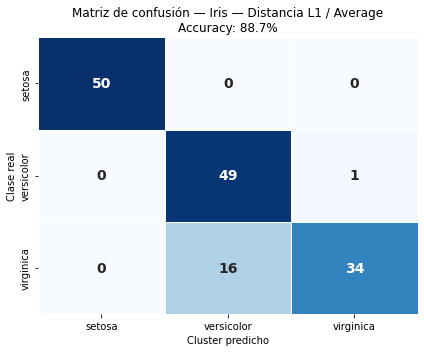

In [377]:
# Umbral calculado por el silhouette
y_pred = fcluster(Z, t=3, criterion='maxclust') - 1


# ── Con etiquetas reales: matriz de confusión ─────────────────────────────
if y_true is not None:

    def alinear_hungarian(y_true, y_pred):
        """Resuelve la permutación de etiquetas con el algoritmo húngaro."""
        k = max(y_true.max(), y_pred.max()) + 1
        C = np.zeros((k, k), dtype=int)
        for t, p in zip(y_true, y_pred):
            C[t, p] += 1
        row, col = linear_sum_assignment(-C)
        mapping  = {c: r for r, c in zip(row, col)}
        return np.array([mapping.get(p, p) for p in y_pred])

    y_alineado = alinear_hungarian(y_true, y_pred)
    cm_matrix  = confusion_matrix(y_true, y_alineado)
    acc        = accuracy_score(y_true, y_alineado)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases,
                linewidths=0.5, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    plt.xlabel('Cluster predicho')
    plt.ylabel('Clase real')
    plt.title(f'Matriz de confusión — {TITULO}\nAccuracy: {acc:.1%}')
    plt.tight_layout()
    plt.show()

# ── Sin etiquetas: perfil de clusters ─────────────────────────────────────
else:
    df_perfil            = pd.DataFrame(X_scaled, columns=df_num.columns)
    df_perfil['cluster'] = y_pred
    perfil               = df_perfil.groupby('cluster').mean()

    fig, ax = plt.subplots(figsize=(11,4))
    perfil.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Perfil medio por cluster — {TITULO}')
    ax.set_xlabel('Variable')
    ax.set_ylabel('Media escalada')
    ax.legend(title='Cluster')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()